In [1]:
!pip install datasets -q

In [2]:
import os
import json
import numpy as np
import pandas as pd
from datasets import load_dataset

In [3]:
dataset = load_dataset("sahil2801/CodeAlpaca-20k")
df = pd.DataFrame(dataset['train'])
df = df[['instruction', 'input', 'output']].copy()
print(df.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/147 [00:00<?, ?B/s]

code_alpaca_20k.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/20022 [00:00<?, ? examples/s]

(20022, 3)


In [4]:
# Checking Data Anomalies
report = {
    "total_samples"       : len(df),
    "null_values"         : df.isnull().sum().to_dict(),
    "empty_instruction"   : (df['instruction'] == '').sum(),
    "empty_output"        : (df['output'] == '').sum(),
    "duplicate_rows"      : df.duplicated().sum(),
    "duplicate_instruction": df['instruction'].duplicated().sum(),
}

for key, val in report.items():
    print(f"{key}: {val}")

total_samples: 20022
null_values: {'instruction': 0, 'input': 0, 'output': 0}
empty_instruction: 0
empty_output: 6
duplicate_rows: 0
duplicate_instruction: 0


In [5]:
# Analyzing token length for all samples
df['token_length'] = df.apply(
    lambda row: len(f"{row['instruction']} {row['input']} {row['output']}".split()),
    axis=1
)

stats = {
    "min"       : df['token_length'].min(),
    "max"       : df['token_length'].max(),
    "mean"      : round(df['token_length'].mean(), 2),
    "median"    : df['token_length'].median(),
    "95th_pct"  : np.percentile(df['token_length'], 95),
    "too_short" : (df['token_length'] < 10).sum(),
    "too_long"  : (df['token_length'] > 512).sum(),
}

for key, val in stats.items():
    print(f"{key}: {val}")

min: 6
max: 488
mean: 43.93
median: 36.0
95th_pct: 97.0
too_short: 71
too_long: 0


In [6]:
# Removing Outliers(large token lengths)
df_clean = df[
    (df['output'] != '') &
    (df['token_length'] >= 10) &
    (df['token_length'] <= 512)
].copy()

df_clean = df_clean.reset_index(drop=True)
print(f"Before: {len(df)}")
print(f"After : {len(df_clean)}")
print(f"Removed: {len(df) - len(df_clean)}")

Before: 20022
After : 19946
Removed: 76


In [7]:
def categorize(instruction):
    instruction = instruction.lower()
    if any(k in instruction for k in ['extract', 'list', 'identify', 'find', 'summarize']):
        return 'extraction'
    elif any(k in instruction for k in ['why', 'should', 'compare', 'analyze', 'explain']):
        return 'reasoning'
    elif any(k in instruction for k in ['what', 'who', 'when', 'where', 'how']):
        return 'qa'
    return 'other'

df_clean['type'] = df_clean['instruction'].apply(categorize)
print(df_clean['type'].value_counts())

type
other         13400
extraction     4486
qa             1531
reasoning       529
Name: count, dtype: int64


In [8]:
qa_samples         = df_clean[df_clean['type'] == 'qa'].sample(600, random_state=42)
reasoning_samples  = df_clean[df_clean['type'] == 'reasoning'].sample(525, random_state=42)
extraction_samples = df_clean[df_clean['type'] == 'extraction'].sample(375, random_state=42)

df_final = pd.concat([qa_samples, reasoning_samples, extraction_samples])
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_final['type'].value_counts())
print(f"Total: {len(df_final)}")

type
qa            600
reasoning     525
extraction    375
Name: count, dtype: int64
Total: 1500


In [9]:
split_idx = int(len(df_final) * 0.8)
train_df  = df_final[:split_idx]
val_df    = df_final[split_idx:]

print(f"Train : {len(train_df)}")
print(f"Val   : {len(val_df)}")

Train : 1200
Val   : 300


In [10]:
def save_jsonl(df, path):
    with open(path, 'w') as f:
        for _, row in df.iterrows():
            sample = {
                "instruction" : row['instruction'],
                "input"       : row['input'],
                "output"      : row['output']
            }
            f.write(json.dumps(sample) + '\n')

os.makedirs("project/data", exist_ok=True)
save_jsonl(train_df, "project/data/train.jsonl")
save_jsonl(val_df,   "project/data/val.jsonl")

print("train.jsonl saved:", len(train_df), "samples")
print("val.jsonl saved  :", len(val_df),   "samples")

train.jsonl saved: 1200 samples
val.jsonl saved  : 300 samples


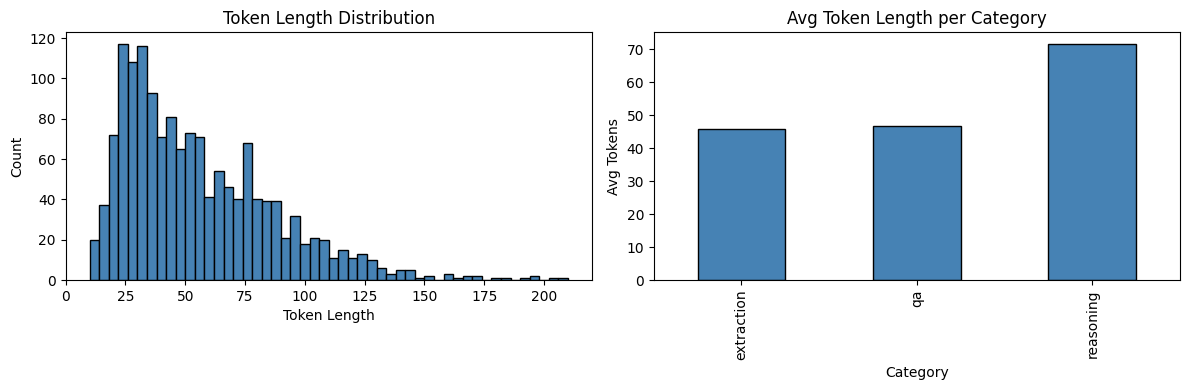

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall token length distribution
axes[0].hist(df_final['token_length'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Token Length Distribution')
axes[0].set_xlabel('Token Length')
axes[0].set_ylabel('Count')

# Category wise distribution
df_final.groupby('type')['token_length'].mean().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='black'
)
axes[1].set_title('Avg Token Length per Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Avg Tokens')

plt.tight_layout()
plt.savefig('project/data/analysis.png')
plt.show()